# CHRD-Bench Sonuçlarının Görselleştirilmesi

Bu notebook çalışmanın posterinde kullanılacak tüm grafik ve tabloları üretmektedir.

Bu notebook içerisinde herhangi bir veri işleme yapılmamaktadır.

Yalnızca daha önce oluşturulan analiz sonuçları okunarak görselleştirilmektedir.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


In [5]:
#Embedding dosyasını oku
df = pd.read_csv(
    "../data/CHRD_Real/metadata_selected.csv",
    sep=";"
)

df.head()

,image_id,file_name,theme,location,motif_1,motif_2,season,contains_people,quality_score,cultural_value,notes
0,CHRD_REAL_0001,CHRD_REAL_0001.jpeg,Rock-cut Heritage,Ürgüp,Cave House,Stone House,Summer,No,NaN,High,NaN
1,CHRD_REAL_0004,CHRD_REAL_0004.jpeg,Village Square,Ürgüp,Street,Local People,Summer,No,NaN,Medium,NaN
2,CHRD_REAL_0005,CHRD_REAL_0005.jpeg,Fairy Chimney,NaN,Rock Formation,Balloon,Summer,No,NaN,High,NaN
3,CHRD_REAL_0006,CHRD_REAL_0006.jpeg,Local Architecture,NaN,Church,Monastery,Summer,No,NaN,Low,NaN
4,CHRD_REAL_0007,CHRD_REAL_0007.jpeg,Daily Life,NaN,Stone House,Street,Summer,No,NaN,Medium,NaN


In [6]:
#Embeddinglere karşılık gelen dosya isimlerini oku
embeddings = np.load(
    "../embeddings/chrd_real_embeddings.npy"
)

print(embeddings.shape)

(82, 768)


In [8]:
import os

print(os.listdir("../embeddings"))

['chrd_real_embeddings.npy', 'chrd_real_image_names.csv']


In [9]:
image_names = pd.read_csv(
    "../embeddings/chrd_real_image_names.csv"
)

image_names.head()

,file_name
0,CHRD_REAL_0001.jpeg
1,CHRD_REAL_0004.jpeg
2,CHRD_REAL_0005.jpeg
3,CHRD_REAL_0006.jpeg
4,CHRD_REAL_0007.jpeg


In [10]:
print("Metadata :", df.shape)
print("Embeddings :", embeddings.shape)
print("Image Names :", image_names.shape)

Metadata : (164, 11)
Embeddings : (82, 768)
Image Names : (82, 1)


# Sonuç Klasörünün Oluşturulması

Poster içerisinde kullanılacak grafikler PNG formatında kaydedilecektir.

Bu nedenle sonuçların saklanacağı klasör oluşturulmaktadır.

In [12]:
RESULTS_FOLDER = "../results"

os.makedirs(RESULTS_FOLDER, exist_ok=True)

print("Sonuç klasörü hazır.")

Sonuç klasörü hazır.


# Tema Dağılımı

Bu grafik veri setindeki kültürel temaların dağılımını göstermektedir.

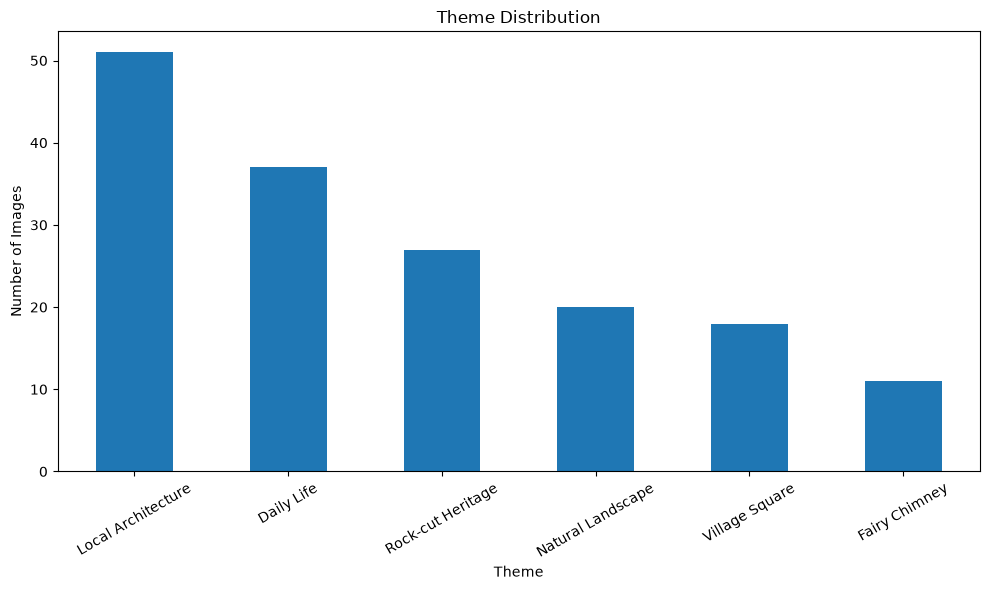

In [13]:
theme_counts = df["theme"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))

theme_counts.plot(kind="bar")

plt.title("Theme Distribution")

plt.xlabel("Theme")

plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_FOLDER, "theme_bar.png"),
    dpi=300
)

plt.show()

# Tema Dağılımı (Pie Chart)

Temaların veri seti içerisindeki yüzdesel dağılımı gösterilmektedir.

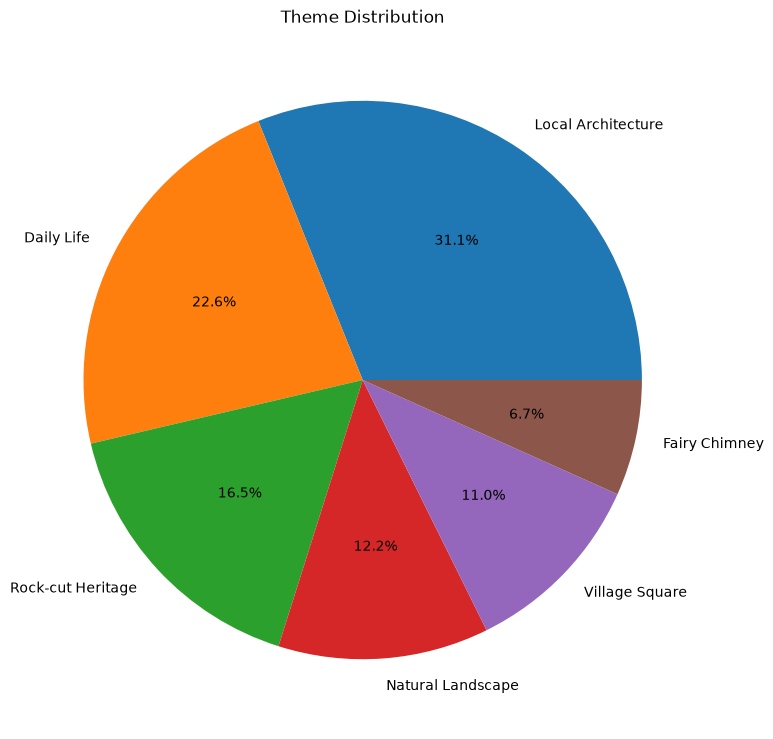

In [14]:
plt.figure(figsize=(8,8))

theme_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Theme Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_FOLDER, "theme_pie.png"),
    dpi=300
)

plt.show();

# Lokasyon Dağılımı

Veri setindeki görsellerin çekildiği lokasyonların dağılımı gösterilmektedir.

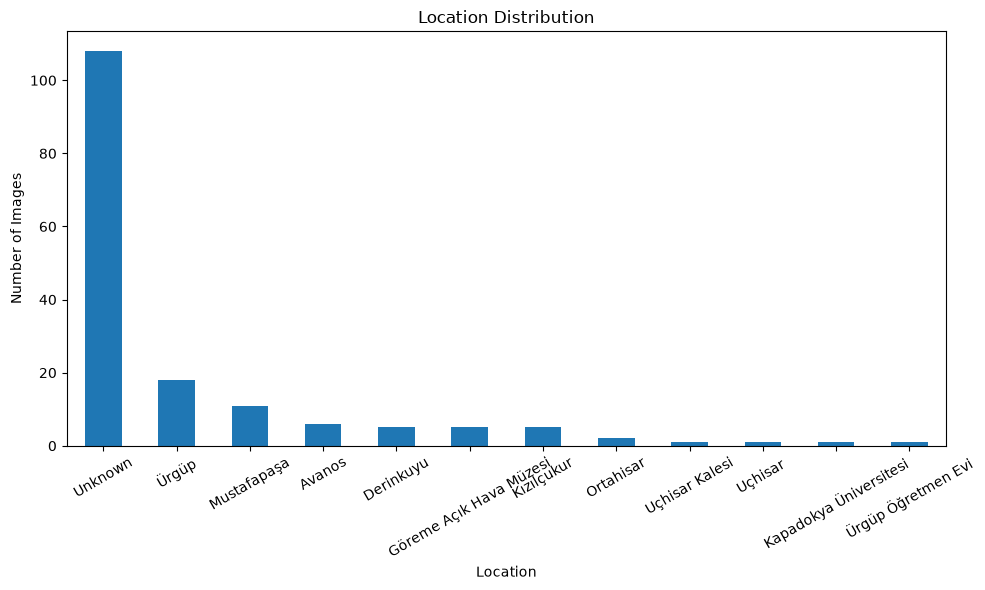

In [15]:
location_counts = (
    df["location"]
    .fillna("Unknown")
    .value_counts()
)

plt.figure(figsize=(10,6))

location_counts.plot(kind="bar")

plt.title("Location Distribution")

plt.xlabel("Location")

plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_FOLDER, "location_bar.png"),
    dpi=300
)

plt.show()

# Motif 1 Dağılımı

Bu grafik veri setinde en sık kullanılan birincil kültürel motifleri göstermektedir.

Motif analizi, veri setinin kültürel çeşitliliğini değerlendirmek amacıyla kullanılmaktadır.

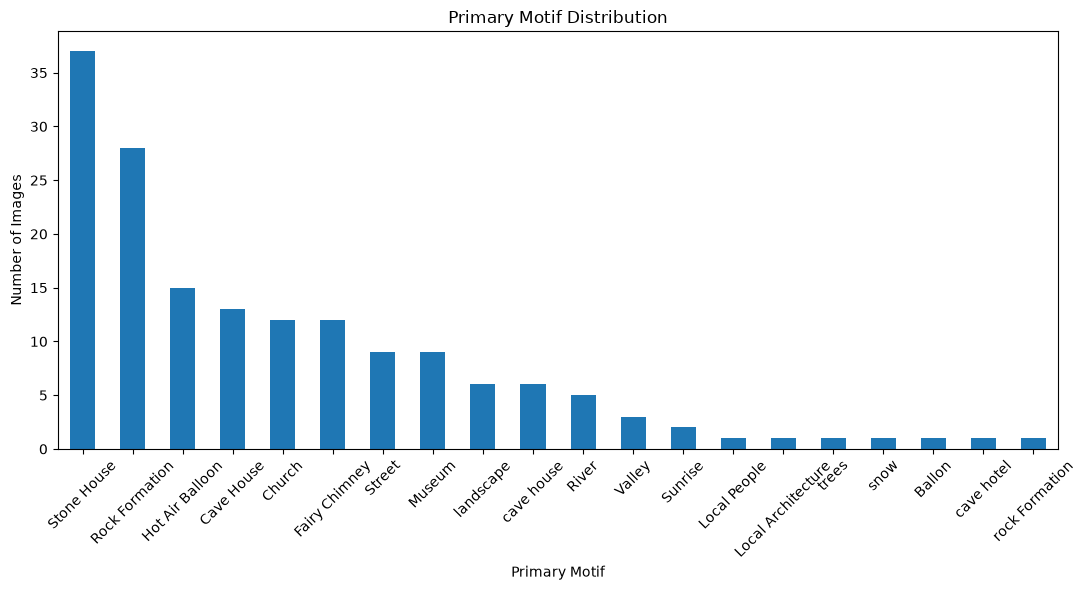

In [16]:
motif1_counts = (
    df["motif_1"]
    .fillna("Unknown")
    .value_counts()
)

plt.figure(figsize=(11,6))

motif1_counts.plot(kind="bar")

plt.title("Primary Motif Distribution")

plt.xlabel("Primary Motif")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_FOLDER,"motif1_bar.png"),
    dpi=300
)

plt.show()

# Motif 2 Dağılımı

Bu grafik veri setindeki ikincil kültürel motiflerin dağılımını göstermektedir.

Birincil motiflerle birlikte değerlendirildiğinde kültürel çeşitlilik daha ayrıntılı incelenebilmektedir.

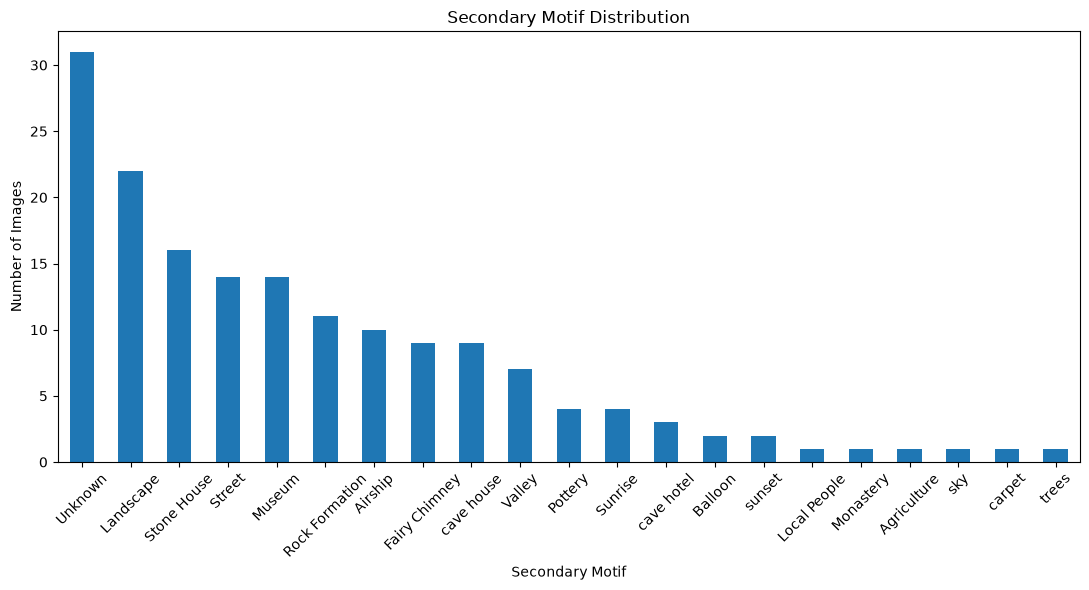

In [17]:
motif2_counts = (
    df["motif_2"]
    .fillna("Unknown")
    .value_counts()
)

plt.figure(figsize=(11,6))

motif2_counts.plot(kind="bar")

plt.title("Secondary Motif Distribution")

plt.xlabel("Secondary Motif")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_FOLDER,"motif2_bar.png"),
    dpi=300
)

plt.show()

# Kültürel Değer Dağılımı

Bu grafik uzman değerlendirmeleri sonucunda belirlenen kültürel değer seviyelerinin dağılımını göstermektedir.

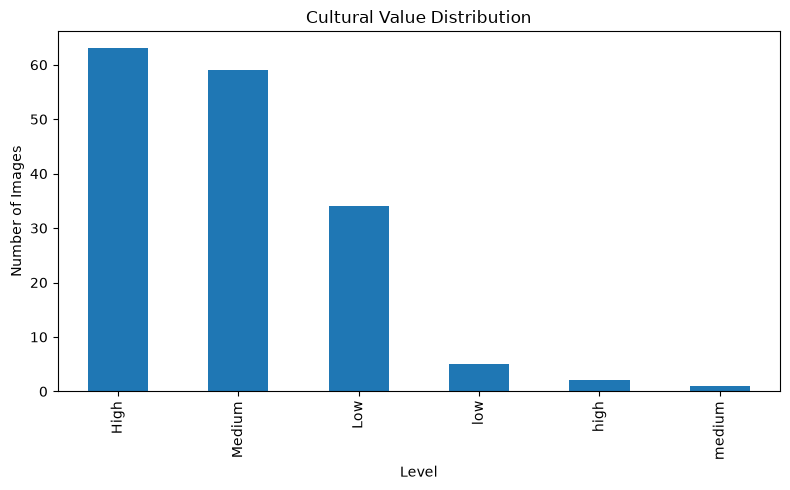

In [18]:
value_counts = (
    df["cultural_value"]
    .fillna("Unknown")
    .value_counts()
)

plt.figure(figsize=(8,5))

value_counts.plot(kind="bar")

plt.title("Cultural Value Distribution")

plt.xlabel("Level")

plt.ylabel("Number of Images")

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_FOLDER,"cultural_value_bar.png"),
    dpi=300
)

plt.show()

# Veri Seti Özeti

Bu bölümde posterde kullanılmak üzere veri setine ait temel istatistikler hesaplanmaktadır.

In [19]:
summary = pd.DataFrame({

    "Statistic":[
        "Total Images",
        "Embedding Count",
        "Theme Count",
        "Location Count",
        "Primary Motif Count",
        "Secondary Motif Count"
    ],

    "Value":[
        len(df),
        len(embeddings),
        df["theme"].nunique(),
        df["location"].nunique(),
        df["motif_1"].nunique(),
        df["motif_2"].nunique()
    ]

})

summary

,Statistic,Value
0,Total Images,164
1,Embedding Count,82
2,Theme Count,6
3,Location Count,11
4,Primary Motif Count,20
5,Secondary Motif Count,20


In [20]:
summary.to_csv(

    os.path.join(
        RESULTS_FOLDER,
        "dataset_summary.csv"
    ),

    index=False,

    encoding="utf-8-sig"
)

print(summary)

               Statistic  Value
0           Total Images    164
1        Embedding Count     82
2            Theme Count      6
3         Location Count     11
4    Primary Motif Count     20
5  Secondary Motif Count     20


# Tema ve Lokasyon İlişkisi

Bu ısı haritası veri setindeki kültürel temaların hangi lokasyonlarda yoğunlaştığını göstermektedir.

Satırlar temaları, sütunlar ise lokasyonları temsil etmektedir.

Renk yoğunluğu ilgili tema-lokasyon eşleşmesindeki görüntü sayısını ifade etmektedir.

In [21]:
theme_location = pd.crosstab(
    df["theme"],
    df["location"].fillna("Unknown")
)

theme_location

location,Avanos,Derinkuyu,Göreme Açık Hava Müzesi,Kapadokya Üniversitesi,Kızılçukur,Mustafapaşa,Ortahisar,Unknown,Uçhisar,Uçhisar Kalesi,Ürgüp,Ürgüp Öğretmen Evi
theme,,,,,,,,,,,,
Daily Life,0,0,1,0,0,0,0,30,0,0,5,1
Fairy Chimney,0,0,0,0,3,0,0,7,1,0,0,0
Local Architecture,0,5,2,1,1,7,0,30,0,0,5,0
Natural Landscape,5,0,0,0,0,1,0,14,0,0,0,0
Rock-cut Heritage,0,0,2,0,1,0,0,23,0,0,1,0
Village Square,1,0,0,0,0,3,2,4,0,1,7,0


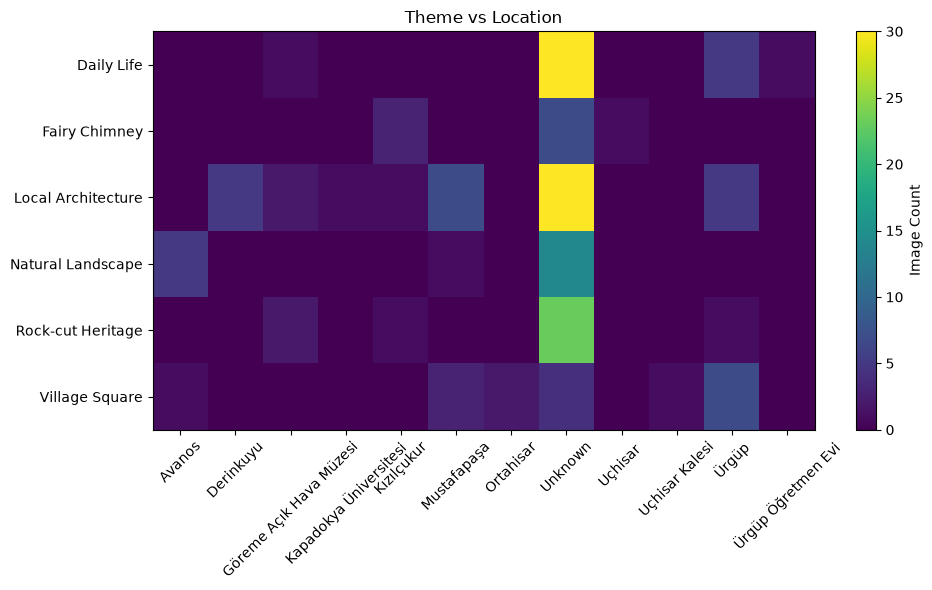

In [22]:
plt.figure(figsize=(10,6))

plt.imshow(
    theme_location,
    aspect="auto"
)

plt.colorbar(label="Image Count")

plt.xticks(
    range(len(theme_location.columns)),
    theme_location.columns,
    rotation=45
)

plt.yticks(
    range(len(theme_location.index)),
    theme_location.index
)

plt.title("Theme vs Location")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_FOLDER,
        "theme_location_heatmap.png"
    ),
    dpi=300
)

plt.show()

# Motif Birliktelik Analizi

Bu analiz birincil ve ikincil motiflerin birlikte görülme sıklığını göstermektedir.

Bu sayede veri setindeki en yaygın kültürel motif kombinasyonları belirlenebilmektedir.

In [23]:
motif_pairs = (

    df.groupby(
        ["motif_1","motif_2"]
    )

    .size()

    .sort_values(ascending=False)

)

motif_pairs.head(15)

motif_1          motif_2       
Stone House      Street            12
Hot Air Balloon  Airship           10
Church           Museum            10
Rock Formation   cave house         7
Fairy Chimney    Rock Formation     7
Cave House       Stone House        6
Rock Formation   Fairy Chimney      6
River            Landscape          5
Rock Formation   Valley             4
                 Landscape          4
Stone House      Landscape          4
Hot Air Balloon  Sunrise            3
Stone House      cave hotel         3
Street           Stone House        3
cave house       Stone House        3
dtype: int64

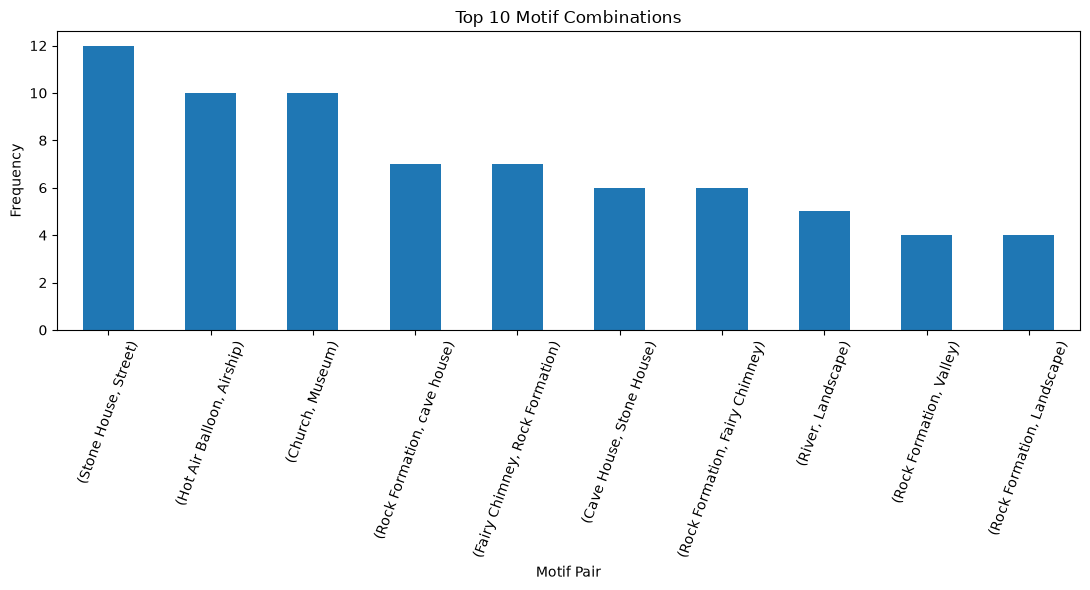

In [24]:
top_pairs = motif_pairs.head(10)

plt.figure(figsize=(11,6))

top_pairs.plot(kind="bar")

plt.title("Top 10 Motif Combinations")

plt.xlabel("Motif Pair")

plt.ylabel("Frequency")

plt.xticks(rotation=70)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_FOLDER,

        "motif_pairs.png"

    ),

    dpi=300

)

plt.show()

# Tema Başına Görsel Sayısı

Bu grafik veri setindeki her kültürel temaya ait görüntü sayılarını yatay çubuk grafik şeklinde göstermektedir.

Bu görselleştirme poster üzerinde okunabilirliği artırmaktadır.

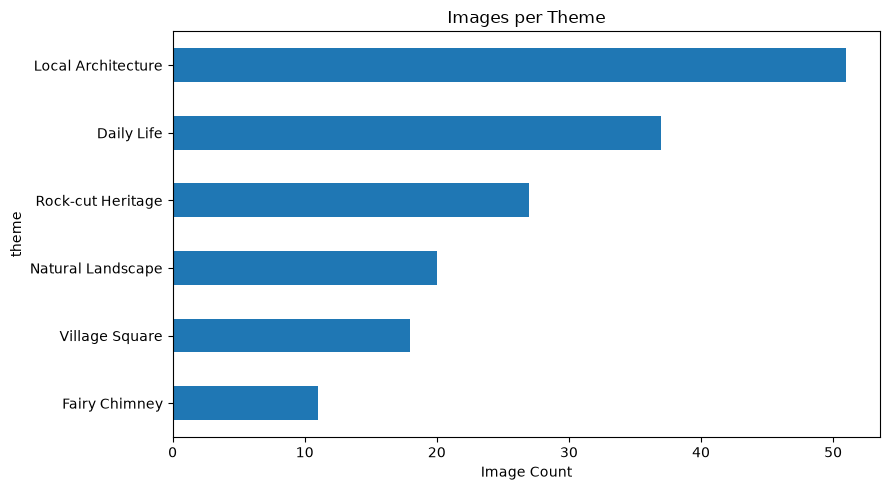

In [25]:
plt.figure(figsize=(9,5))

theme_counts.sort_values().plot(kind="barh")

plt.title("Images per Theme")

plt.xlabel("Image Count")

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_FOLDER,

        "theme_horizontal.png"

    ),

    dpi=300

)

plt.show()

# Lokasyon Yoğunluğu

Bu grafik veri setinde en fazla görüntü içeren lokasyonları göstermektedir.

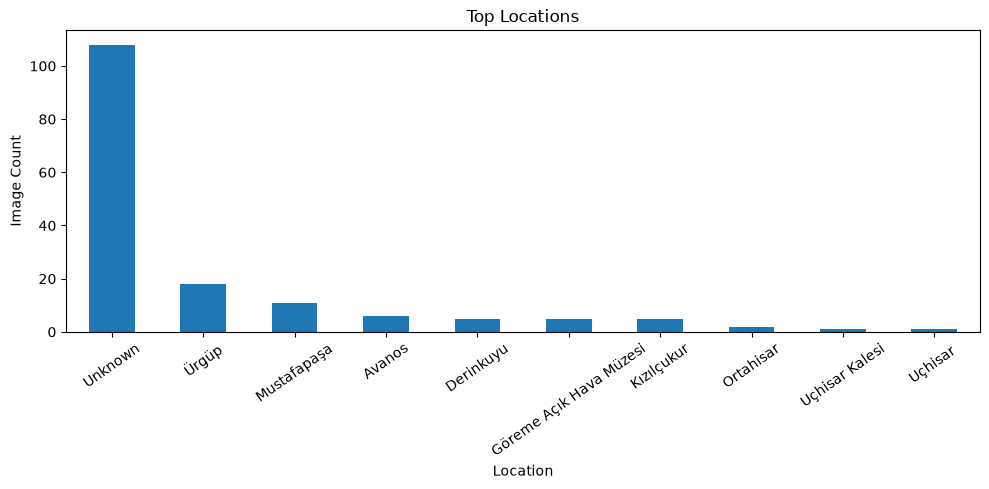

In [26]:
top_locations = location_counts.head(10)

plt.figure(figsize=(10,5))

top_locations.plot(kind="bar")

plt.title("Top Locations")

plt.xlabel("Location")

plt.ylabel("Image Count")

plt.xticks(rotation=35)

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULTS_FOLDER,

        "top_locations.png"

    ),

    dpi=300

)

plt.show()

# Sonuç Dosyalarının Kontrolü

Bu bölümde poster için oluşturulan tüm grafiklerin başarıyla kaydedildiği doğrulanmaktadır.

In [27]:
print("Poster için oluşturulan dosyalar:\n")

for file in sorted(os.listdir(RESULTS_FOLDER)):
    print(file)

Poster için oluşturulan dosyalar:

chrd_similarity_results.csv
cultural_value_bar.png
dataset_summary.csv
location_bar.png
motif1_bar.png
motif2_bar.png
motif_pairs.png
real_image_similarity.csv
theme_bar.png
theme_horizontal.png
theme_location_heatmap.png
theme_pie.png
top_locations.png
